In [11]:
from pandas import DataFrame,read_csv
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
import warnings
warnings.filterwarnings("ignore")

import joblib

In [2]:
df = read_csv("data/Housing.csv")

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [5]:
df.shape

(545, 13)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

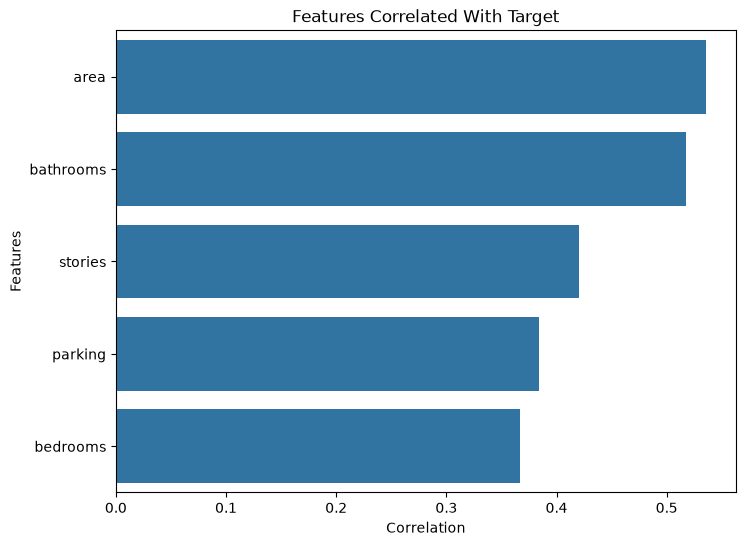

In [12]:
plt.figure(figsize=(8,6))

corr = (
    df.corr(numeric_only=True)["price"].drop("price").abs().sort_values(ascending=False))

sns.barplot(
    x=corr.values,
    y=corr.index
)

plt.title("Features Correlated With Target")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.savefig(f"images/Absolute_Corralation.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

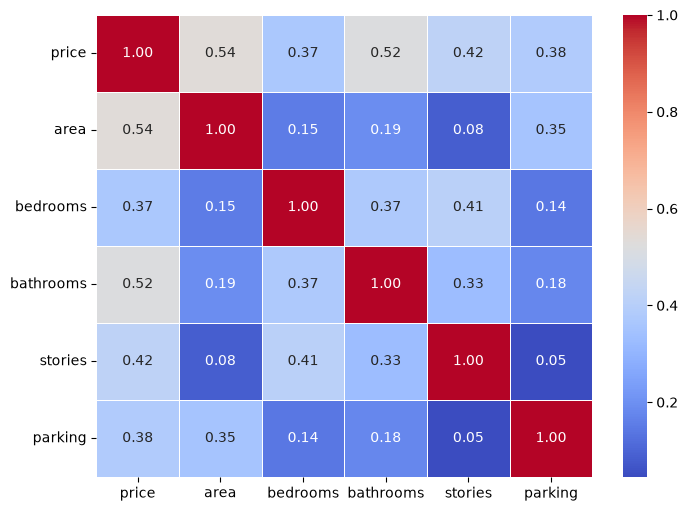

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),fmt=".2f",annot=True,cmap="coolwarm",linewidths=0.5)
plt.yticks(rotation=0.01)
plt.savefig(f"images/HeatMap.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

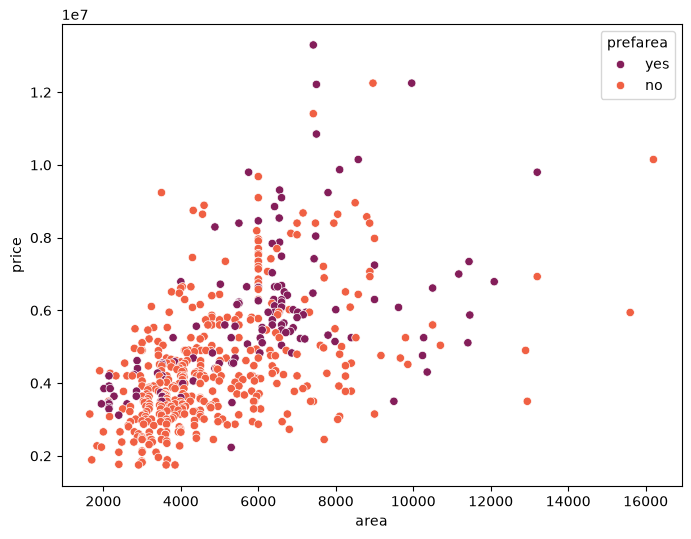

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(df,x="area",y="price",palette="rocket",hue="prefarea")
plt.savefig(f"images/ScatterPlot.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

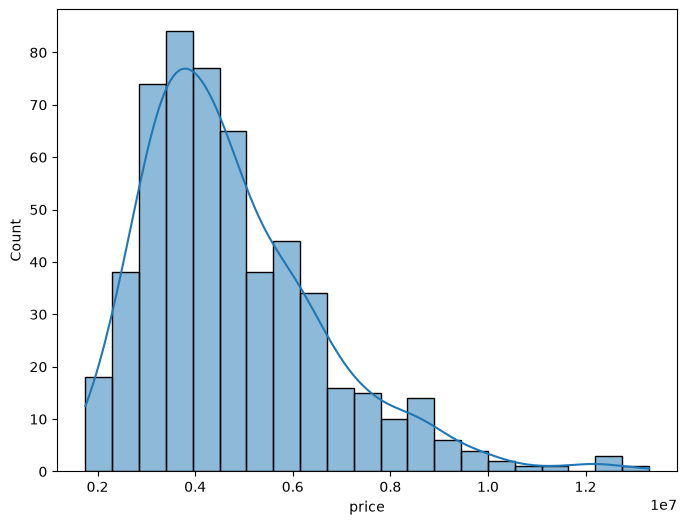

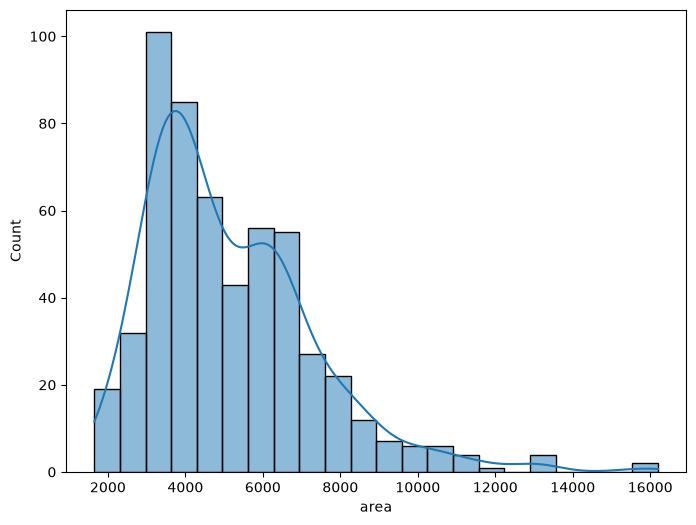

In [15]:
plt.figure(figsize=(8,6))
sns.histplot(df,x="price",kde=True)
plt.savefig(f"images/HistPlot_by_price_col.png",
        dpi=300,
        bbox_inches="tight")
plt.show()



plt.figure(figsize=(8,6))
sns.histplot(df,x="area",kde=True)
plt.savefig(f"images/HistPlot_by_area_col.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

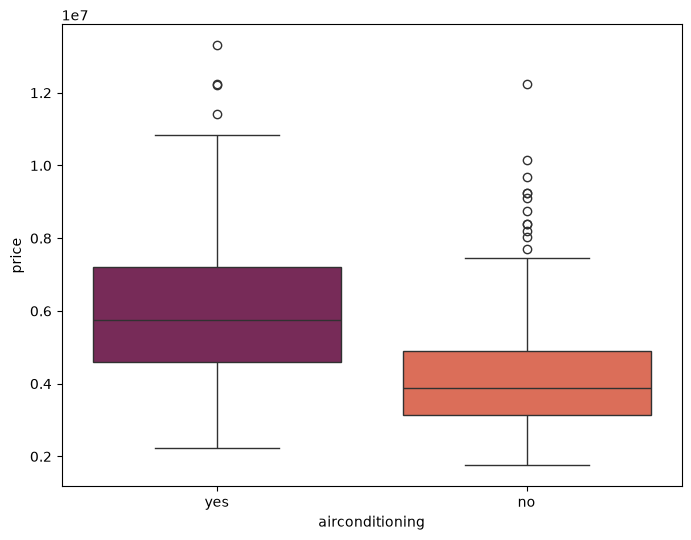

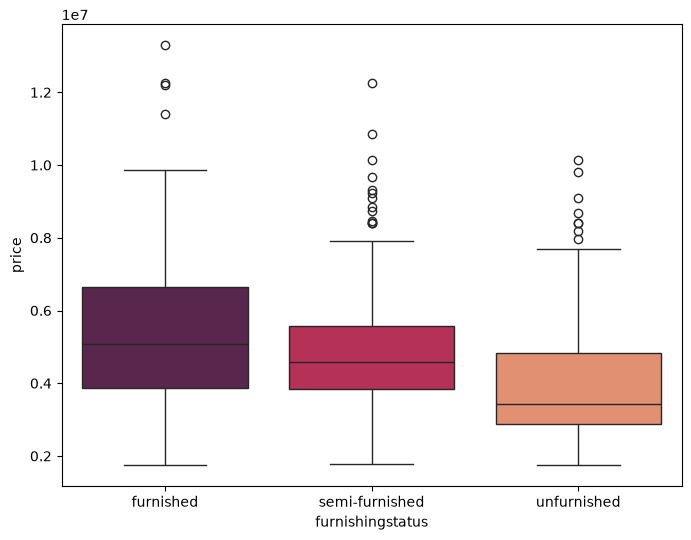

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(df,x="airconditioning",y="price",palette="rocket",hue="airconditioning")
plt.savefig(f"images/BoxPlot_1.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(df,x="furnishingstatus",y="price",palette="rocket",hue="furnishingstatus")
plt.savefig(f"images/BoxPlot_2.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

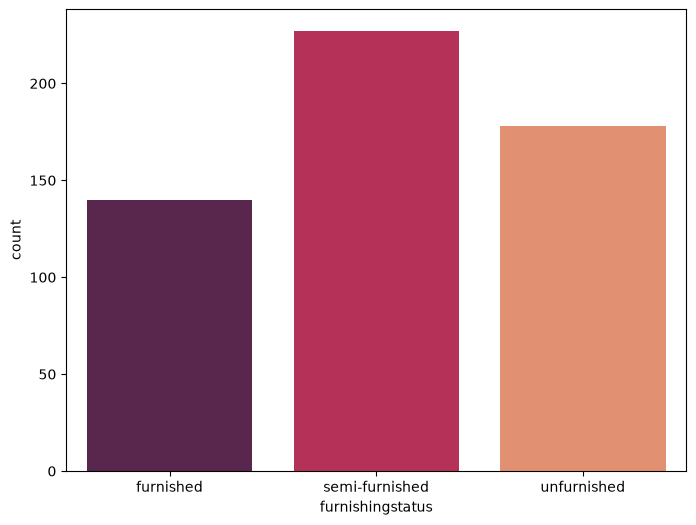

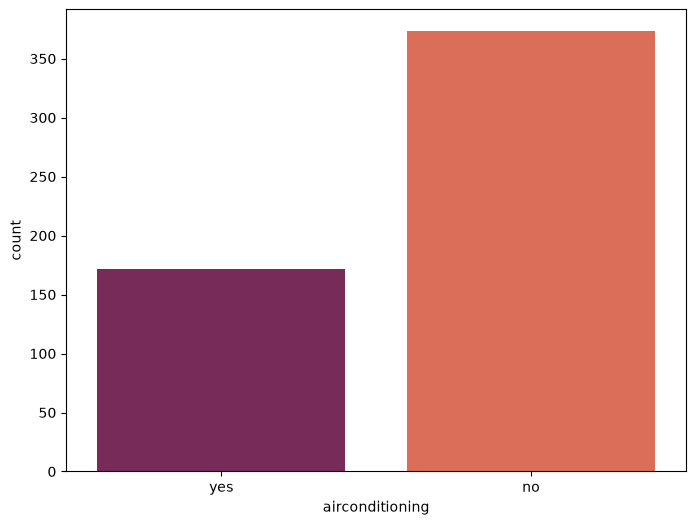

In [17]:
plt.figure(figsize=(8,6))
sns.countplot(df,x="furnishingstatus",palette="rocket",legend=False,hue="furnishingstatus")
plt.savefig(f"images/CountPlot_1.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,6))
sns.countplot(df,x="airconditioning",palette="rocket",hue="airconditioning",legend=False)
plt.savefig(f"images/CountPlot_2.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [3]:
X,y = df.drop("price",axis=1),df["price"]

x_train,x_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

categorical = X.select_dtypes(include="str").columns
numerical = X.select_dtypes(include="number").columns

In [4]:
preprocessor = ColumnTransformer([("num",Pipeline([("scaler", StandardScaler())]),numerical),("cat",OneHotEncoder(handle_unknown="ignore"),categorical)])

In [5]:
pipe = Pipeline([("prep",preprocessor),("model",LinearRegression())])

In [6]:
param = [

    {
        "prep__num__scaler":[StandardScaler(),RobustScaler()],
        "model": [LinearRegression()],
        "model__fit_intercept": [True, False],
        "model__positive": [True, False]
    },

    {
        "prep__num__scaler":["passthrough"],
        "model": [RandomForestRegressor()],
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": [1.0, "sqrt", "log2"]
    },

    {
        "prep__num__scaler":["passthrough"],
        "model": [GradientBoostingRegressor()],
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 5],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__subsample": [0.8, 1.0]
    },

    {
        "prep__num__scaler":["passthrough"],
        "model": [XGBRegressor()],
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__min_child_weight": [1, 3, 5],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    },

    {
        "prep__num__scaler":[StandardScaler(),RobustScaler()],
        "model": [KNeighborsRegressor()],
        "model__n_neighbors": [3, 5, 7, 10, 15],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    }
]

In [7]:
grid = RandomizedSearchCV(pipe,param,n_iter=50,cv=5,verbose=1,n_jobs=-1,scoring="neg_root_mean_squared_error",)

In [8]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model': [LinearRegression()], 'model__fit_intercept': [True, False], 'model__positive': [True, False], 'prep__num__scaler': [StandardScaler(), RobustScaler()]}, {'model': [RandomForestRegressor()], 'model__max_depth': [None, 5, ...], 'model__max_features': [1.0, 'sqrt', ...], 'model__min_samples_leaf': [1, 2, ...], ...}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` an

In [9]:
best = grid.best_estimator_

print("grid.best_score_ : ",grid.best_score_)
print("grid.best_estimator_ : ",grid.best_estimator_)
print("grid.best_params_ :",grid.best_params_)

grid.best_score_ :  -1045413.917681247
grid.best_estimator_ :  Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   'passthrough')]),
                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='str')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str'))])),
                ('model',
                 RandomForestRegressor(max_depth=20, max_features='log2',
                                       min_samples_leaf=2, min_samples_split=5,
                                       n_e

In [10]:
y_pred = best.predict(x_test)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

p = {
    "MAE_score":mae,
    "MSE_score":mse,
    "RMSE_score":rmse,
    "R2_score":r2
}

p = DataFrame(p,index=[""])
p

,MAE_score,MSE_score,RMSE_score,R2_score
,1.032893e+06,2.022632e+12,1.422193e+06,0.599841


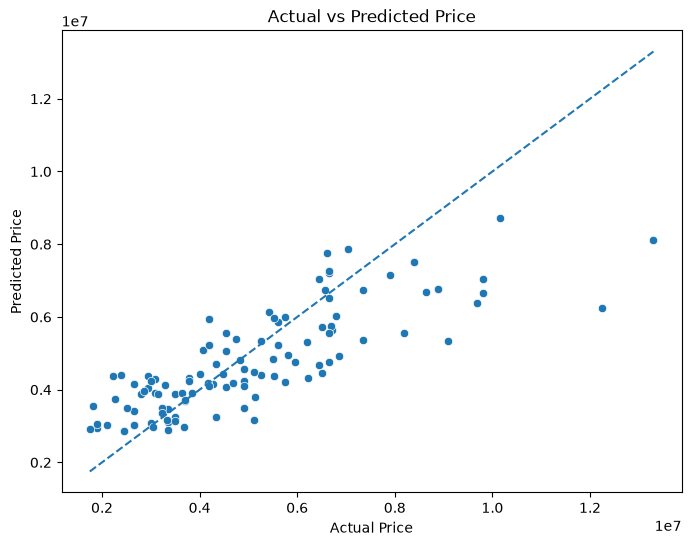

In [26]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test,y=y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],linestyle="--")
plt.savefig(f"images/Diff_Actual_vs_PridictedPrice.png",
        dpi=300,
        bbox_inches="tight")

plt.show()

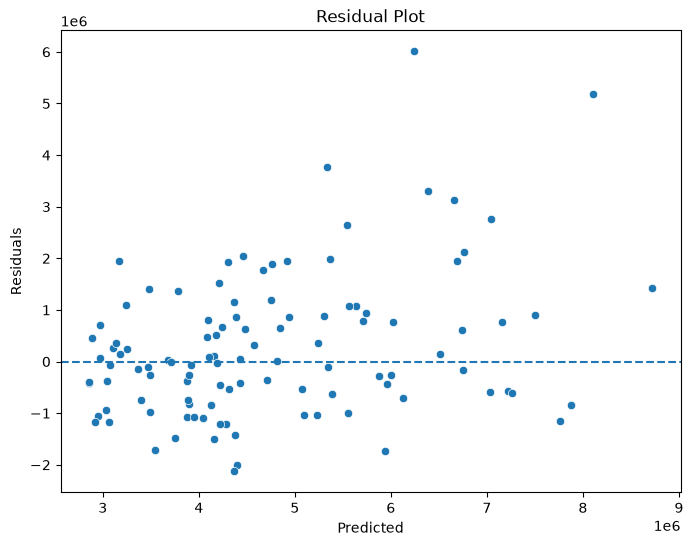

In [27]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_pred,y=residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig(f"images/Residual_Actual_vs_PridictedPrice.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [12]:
joblib.dump(grid.best_estimator_,"models/Heart_model.joblib")
print("model saved")

model saved
